# Random Forest Modeling

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import statsmodels.api as sm

In [3]:
# Load the dataset
data = pd.read_csv("UCI_Credit_Card.csv")

data.shape

(30000, 25)

### Preparing the data for modeling

In [4]:

# Remove the "ID" column if it exists, as it is not a predictive feature
if "ID" in data.columns:
    data = data.drop(columns="ID")

# Regrouping rare categories in "EDUCATION" and "MARRIAGE" 
data["EDUCATION"] = data["EDUCATION"].replace({
    0: "Other",
    4: "Other",
    5: "Other",
    6: "Other"
}).astype(str)

data["MARRIAGE"] = data["MARRIAGE"].replace({
    0: "Other",
    3: "Other"
}).astype(str)

# Convert to string type for one-hot encoding
data["SEX"] = data["SEX"].astype(str)

target = "default.payment.next.month"

## 3. Train/Test Split and Preprocessing

In [5]:
# Split the data into features and target variable
X = data.drop(columns=[target])
y = data[target].astype(int)

# Split the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (21000, 23)
Test size: (9000, 23)


In [6]:
# categorical features to be one-hot encoded
categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]

numeric_features = [col for col in X.columns if col not in categorical_features]

In [7]:
# Define the column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features) # drop="first" to avoid dummy variable trap
    ],
    remainder="passthrough" # keep the numeric features as they are
)

# Fit the preprocessor on the training data and transform both training and testing data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Get the feature names after one-hot encoding
encoded_cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)

feature_names = list(encoded_cat_features) + numeric_features

# Convert the transformed arrays back to DataFrames for easier handling
X_train_array = X_train_transformed.toarray() if hasattr(X_train_transformed, "toarray") else X_train_transformed
X_test_array = X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray") else X_test_transformed

# Create DataFrames with the correct feature names and indices
X_train_df = pd.DataFrame(X_train_array, columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_array, columns=feature_names, index=X_test.index)

## Random Forest Modeling

In [ ]:
# Fit The Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

forest.fit(X_train_df, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [9]:
# Predict probabilities for the positive class (default)
rf_pred = forest.predict_proba(X_test_df)[:,1]

In [10]:
# AUC calculation
from sklearn.metrics import roc_auc_score

rf_auc = roc_auc_score(y_test, rf_pred)

print("Random Forest AUC:", round(rf_auc,3))

Random Forest AUC: 0.764


In [12]:
# Feature importance
rf_importance = pd.DataFrame({
    "Feature": X_train_df.columns,
    "Importance": forest.feature_importances_
})

rf_importance = rf_importance.sort_values("Importance", ascending=False)

rf_importance.head(10)

,Feature,Importance
8,PAY_0,0.098271
6,LIMIT_BAL,0.063695
7,AGE,0.062442
14,BILL_AMT1,0.061867
20,PAY_AMT1,0.052999
15,BILL_AMT2,0.052590
21,PAY_AMT2,0.052344
16,BILL_AMT3,0.050227
22,PAY_AMT3,0.048839
17,BILL_AMT4,0.048610


<Figure size 1000x600 with 0 Axes>

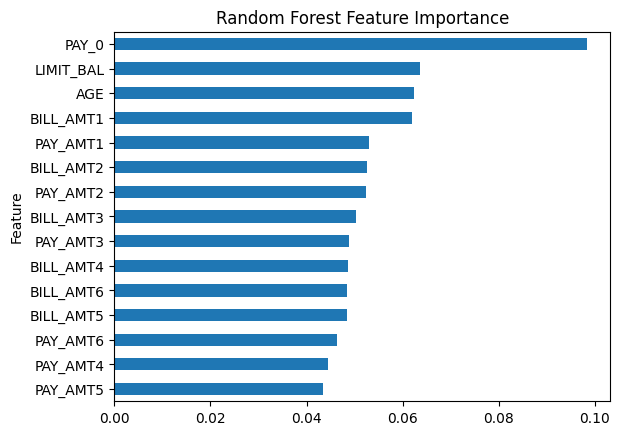

In [13]:
# Vizualize feature importance
plt.figure(figsize=(10,6))

rf_importance.head(15).sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.show()

The Random Forest model provides an alternative machine learning approach that can capture non-linear relationships between variables.

While logistic regression remains more interpretable and commonly used in regulatory credit scoring models, tree-based models can provide higher predictive performance.

Comparing both approaches allows us to balance interpretability and predictive power.

Comparing logistic regression and Random Forest results shows consistent patterns. Both models highlight payment behaviour variables as the most important predictors of default risk. This confirms that recent payment delays and repayment amounts are the main drivers of credit risk in this dataset.